In [1]:
import pandas as pd
import numpy as np
from src.evaluate import evaluate_model
from src.data_engineering import add_trend, add_house_age, add_renovation_flag

In [2]:
df = pd.read_csv('data/kc_house_data.csv')
unseen_data = pd.read_csv('data/future_unseen_examples.csv')
demographics = pd.read_csv('data/zipcode_demographics.csv')

In [3]:
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [4]:
unseen_data = unseen_data.merge(demographics, on='zipcode', how='left')

In [5]:
current_model = pd.read_pickle('model/model.pkl')

In [6]:
import json
model_features = json.load(open('model/model_features.json', 'r'))

def predict_price(input_df, model, model_features):
    input_df = input_df[model_features]
    prediction = model.predict(input_df)
    return prediction

In [7]:
predict_price(unseen_data, current_model, model_features)

array([ 458520. ,  612800. ,  449160. ,  679700. ,  304256. ,  553798. ,
        341800. ,  445350. ,  990500. ,  532940. ,  422700. ,  484220. ,
        499400. ,  358470. ,  790700. ,  236300. ,  426950. ,  687600. ,
        619880. ,  438000. ,  520800. ,  669300.2,  549036. ,  411100. ,
        250190. ,  313590. ,  730800. ,  285730. ,  256990. ,  390200. ,
        285942.4,  865700. ,  975500. ,  494936. ,  272090. ,  297900. ,
        302298. ,  612000. ,  222590. ,  297940. ,  213800. ,  796988. ,
        407260. ,  307300. ,  451000. ,  263660. ,  297560. ,  658200. ,
        261500. ,  288890. , 1241796. ,  279380. ,  252390. ,  252980. ,
        569370. ,  524790. ,  602670. ,  427900. ,  406000. ,  890000. ,
        486090. ,  317402. ,  886700. ,  421650. ,  321999. ,  390360. ,
        486980. ,  499000. ,  344200. ,  558650. ,  264590. ,  711190. ,
        259930. ,  614000. ,  424089.8,  522800. ,  520300. ,  412600. ,
        830000. ,  258906. ,  726500. ,  565600. , 

In [8]:
unseen_data.columns

Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'ppltn_qty', 'urbn_ppltn_qty',
       'sbrbn_ppltn_qty', 'farm_ppltn_qty', 'non_farm_qty',
       'medn_hshld_incm_amt', 'medn_incm_per_prsn_amt', 'hous_val_amt',
       'edctn_less_than_9_qty', 'edctn_9_12_qty', 'edctn_high_schl_qty',
       'edctn_some_clg_qty', 'edctn_assoc_dgre_qty', 'edctn_bchlr_dgre_qty',
       'edctn_prfsnl_qty', 'per_urbn', 'per_sbrbn', 'per_farm', 'per_non_farm',
       'per_less_than_9', 'per_9_to_12', 'per_hsd', 'per_some_clg',
       'per_assoc', 'per_bchlr', 'per_prfsnl'],
      dtype='object')

In [9]:
df

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,20140521T000000,360000.0,3,2.50,1530,1131,3.0,0,0,...,8,1530,0,2009,0,98103,47.6993,-122.346,1530,1509
21609,6600060120,20150223T000000,400000.0,4,2.50,2310,5813,2.0,0,0,...,8,2310,0,2014,0,98146,47.5107,-122.362,1830,7200
21610,1523300141,20140623T000000,402101.0,2,0.75,1020,1350,2.0,0,0,...,7,1020,0,2009,0,98144,47.5944,-122.299,1020,2007
21611,291310100,20150116T000000,400000.0,3,2.50,1600,2388,2.0,0,0,...,8,1600,0,2004,0,98027,47.5345,-122.069,1410,1287


In [10]:
df.isnull().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'bedrooms'}>,
        <Axes: title={'center': 'bathrooms'}>,
        <Axes: title={'center': 'sqft_living'}>],
       [<Axes: title={'center': 'sqft_lot'}>,
        <Axes: title={'center': 'floors'}>,
        <Axes: title={'center': 'waterfront'}>,
        <Axes: title={'center': 'view'}>],
       [<Axes: title={'center': 'condition'}>,
        <Axes: title={'center': 'grade'}>,
        <Axes: title={'center': 'sqft_above'}>,
        <Axes: title={'center': 'sqft_basement'}>],
       [<Axes: title={'center': 'yr_built'}>,
        <Axes: title={'center': 'yr_renovated'}>,
        <Axes: title={'center': 'zipcode'}>,
        <Axes: title={'center': 'lat'}>],
       [<Axes: title={'center': 'long'}>,
        <Axes: title={'center': 'sqft_living15'}>,
        <Axes: title={'center': 'sqft_lot15'}>, <Axes: >]], dtype=object)

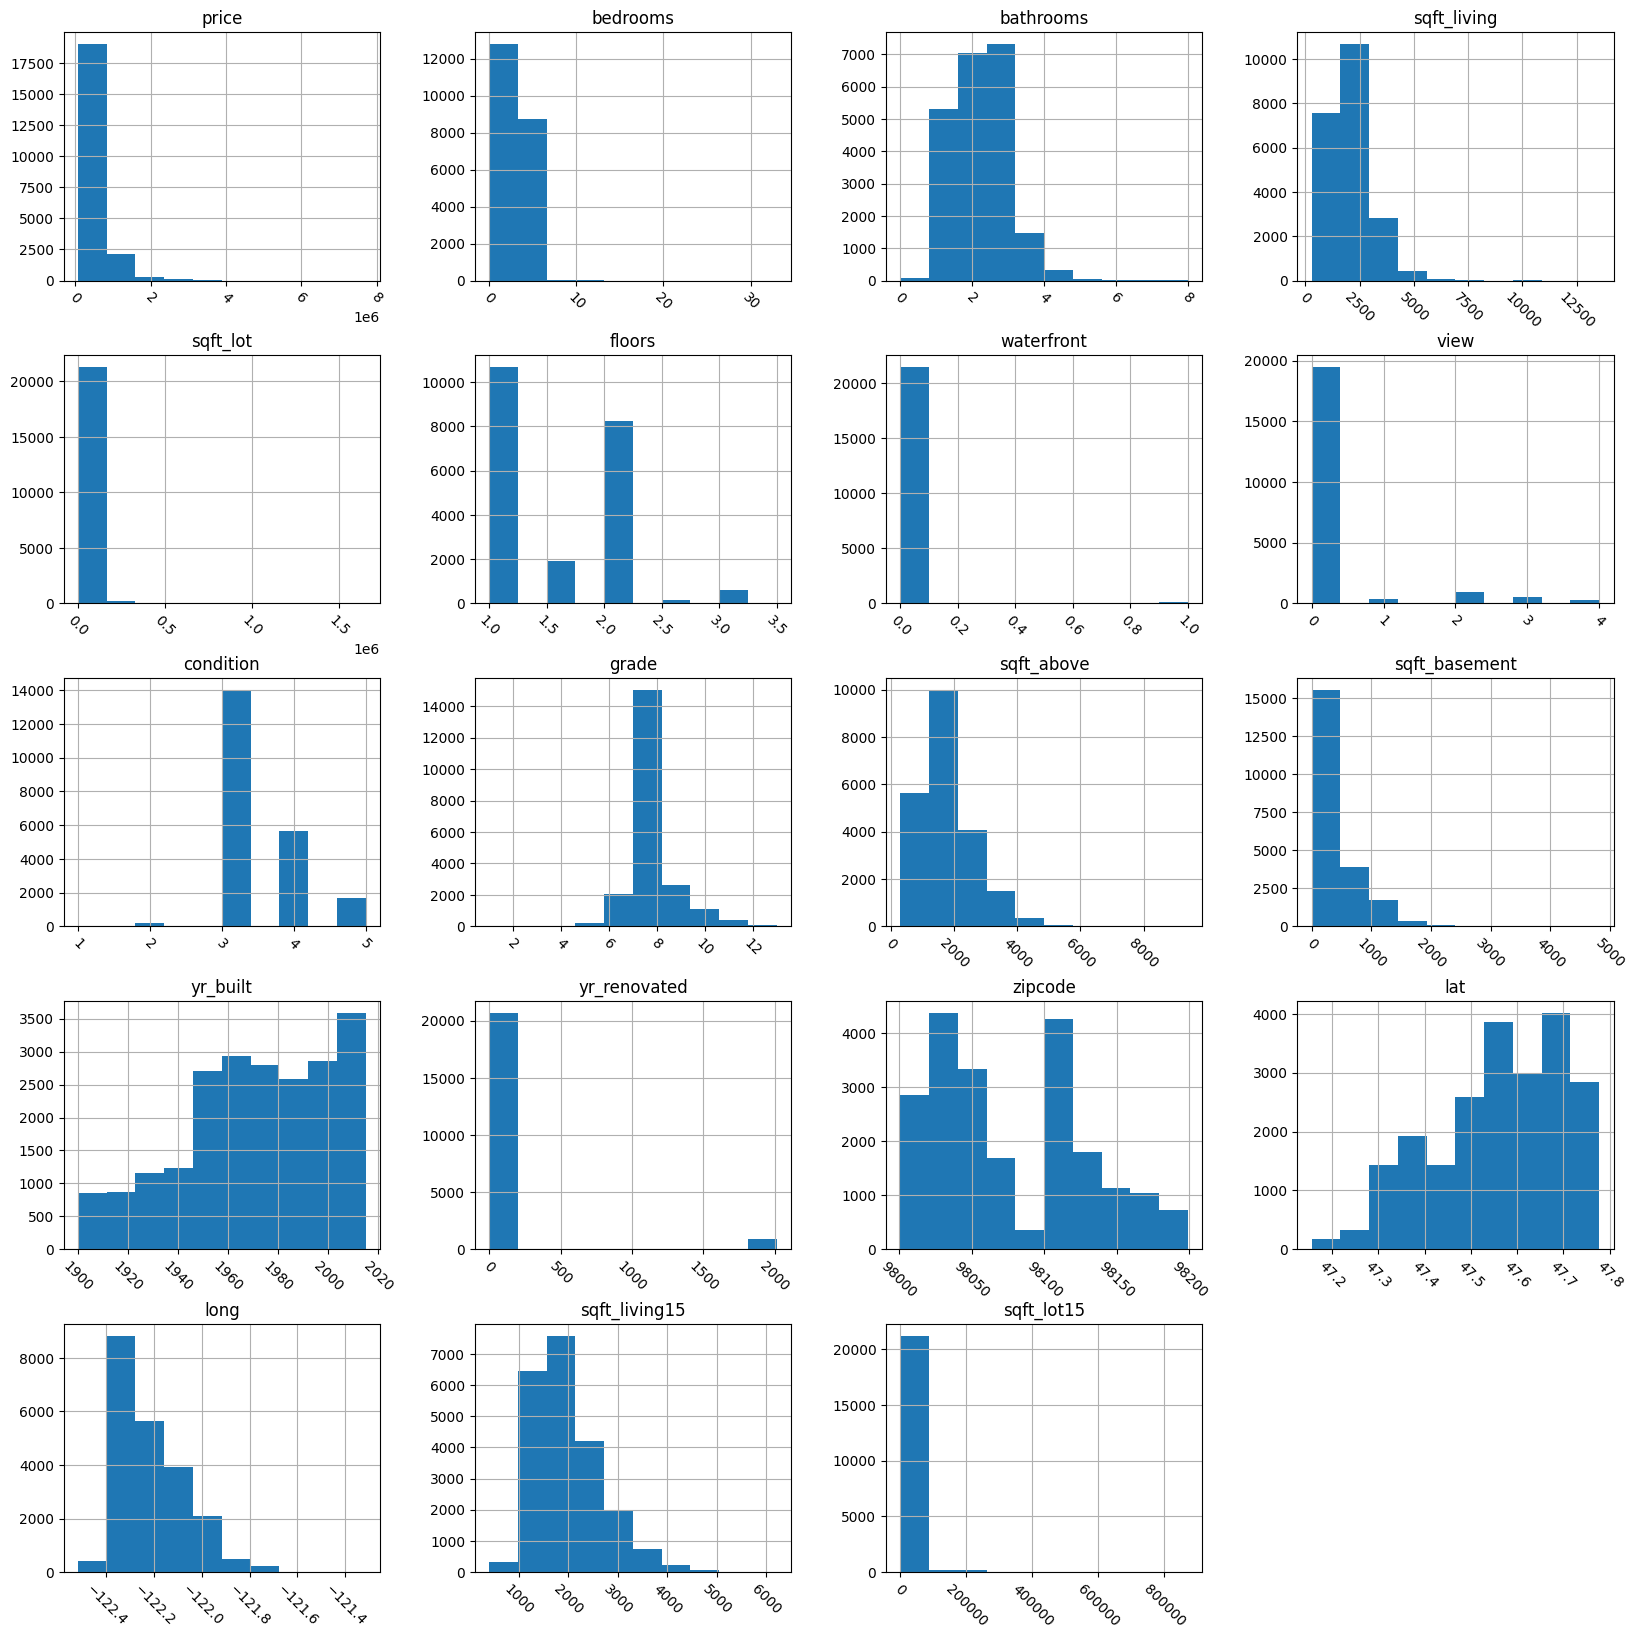

In [11]:
df.iloc[:, 2:].hist(figsize=(20,20), xrot=-45)

<Axes: >

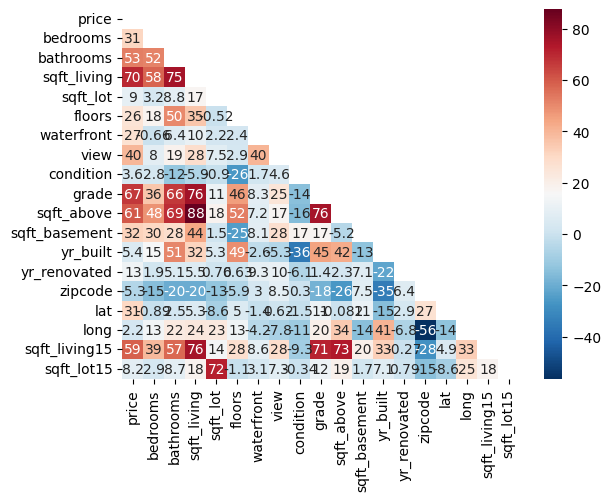

In [12]:
import seaborn as sns

mask = np.zeros_like(df.iloc[:, 2:].corr(), dtype=bool)
mask[np.triu_indices_from(mask)] = True
# heatmap
sns.heatmap(df.iloc[:, 2:].corr()*100, 
           cmap='RdBu_r', 
           annot = True, 
           mask = mask)

In [13]:
df.iloc[df.yr_built.idxmax()]

id                    9385200045
date             20150512T000000
price                   729500.0
bedrooms                       3
bathrooms                    2.5
sqft_living                 1660
sqft_lot                    1091
floors                       3.0
waterfront                     0
view                           1
condition                      3
grade                          9
sqft_above                  1530
sqft_basement                130
yr_built                    2015
yr_renovated                   0
zipcode                    98116
lat                      47.5818
long                    -122.402
sqft_living15               1510
sqft_lot15                  1352
Name: 643, dtype: object

In [ ]:
#df = df.merge(demographics[["zipcode", "hous_val_amt"]], on='zipcode', how='left')
cols_to_drop = ["zipcode", "sqft_living15", "sqft_lot15"]
data = df.drop(columns=cols_to_drop)

In [15]:
data["date"] = pd.to_datetime(data.date)

In [16]:
data.date.max() - data.date.min()

Timedelta('390 days 00:00:00')

In [17]:
data = add_trend(data)
data = add_renovation_flag(data)
data = add_house_age(data)
data = add_house_age(data, built_col='yr_renovated', age_col='renovation_age')

In [18]:
from datetime import timedelta

last_date = data.date.max()
val_data = data[data.date > (last_date - timedelta(30))]

In [19]:
data.drop(val_data.index, inplace=True)
last_date = data.date.max()
test_data = data[data.date > (last_date - timedelta(30))]
data.drop(test_data.index, inplace=True)

In [20]:
X_train = data.drop(columns=['id', 'date', 'price'])
y_train = data['price']

X_test = test_data.drop(columns=['id', 'date', 'price'])
y_test = test_data['price']

  0%|          | 0/50 [00:00<?, ?trial/s, best loss=?]

c:\Users\Lourenço\AppData\Local\pypoetry\Cache\virtualenvs\house-pricing-R782PnHK-py3.9\lib\site-packages\hyperopt\atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


100%|██████████| 50/50 [01:12<00:00,  1.45s/trial, best loss: 0.12643492179163535]
Best hyperparameters: {'colsample_bytree': 0.8168380607904719, 'gamma': 0.015559331365696316, 'learning_rate': 0.04271778557085637, 'max_depth': 10, 'min_child_weight': 8, 'n_estimators': 300, 'reg_alpha': 0.01713817468677412, 'reg_lambda': 0.004756365136909848, 'subsample': 0.8625695321860891}
{'MSE': 15116425361.087177, 'MAE': 71301.28191696643, 'MAPE': 0.12560607938081197}


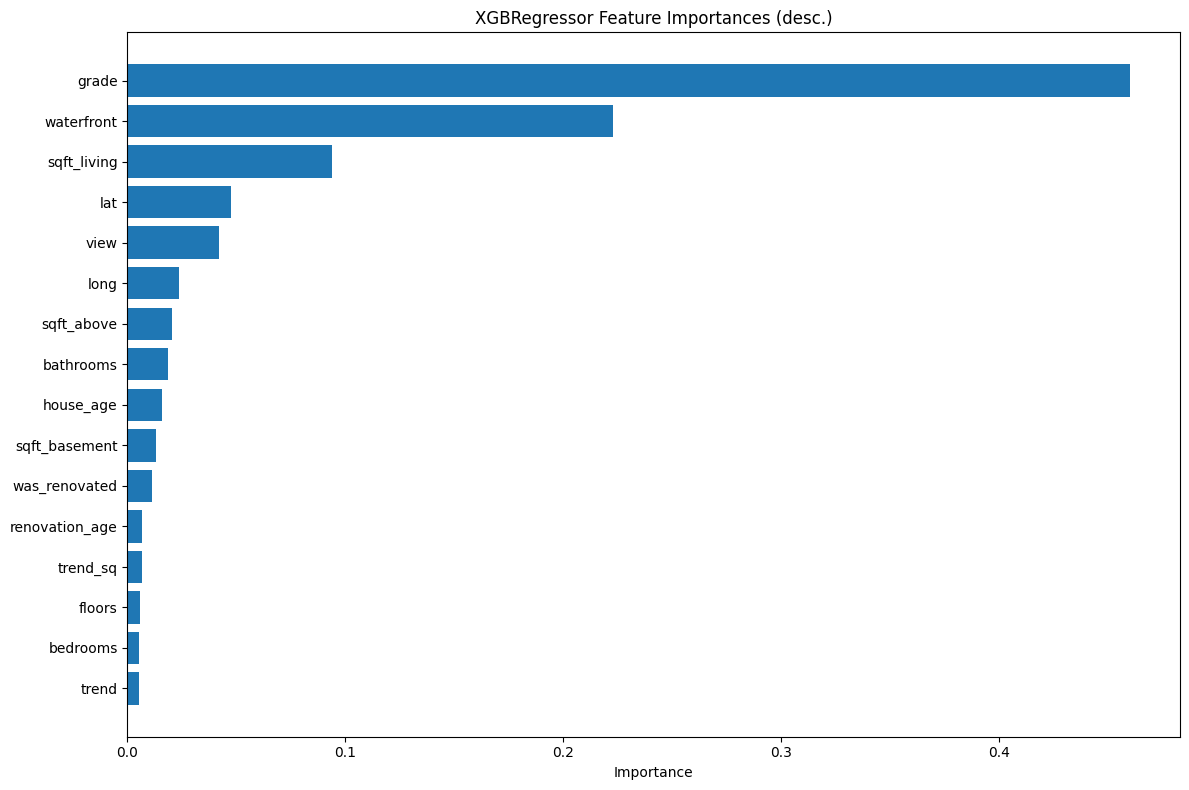

In [21]:
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

# 1) Define the search space
space = {
    'n_estimators':    hp.choice('n_estimators',    [100, 200, 300, 500]),
    'max_depth':       hp.quniform('max_depth',    3, 10, 1),
    'learning_rate':   hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample':       hp.uniform('subsample',      0.6, 1.0),
    'colsample_bytree':hp.uniform('colsample_bytree',0.6, 1.0),
    'gamma':           hp.uniform('gamma',          0,   5),
    'min_child_weight':hp.quniform('min_child_weight', 1, 10, 1),
    'reg_alpha':       hp.loguniform('reg_alpha',    np.log(1e-3), np.log(10)),
    'reg_lambda':      hp.loguniform('reg_lambda',   np.log(1e-3), np.log(10)),
}

# 2) Objective: 5‑fold CV MAPE
def objective(params):
    # cast integers
    params['max_depth'] = int(params['max_depth'])
    params['min_child_weight'] = int(params['min_child_weight'])

    model = XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        **params
    )

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    neg_mape = cross_val_score(
        model,
        X_train, y_train,
        scoring='neg_mean_absolute_percentage_error',
        cv=cv,
        n_jobs=-1
    ).mean()
    mape = -neg_mape
    return {'loss': mape, 'status': STATUS_OK}

# 3) Run optimization
trials = Trials()
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(42)
)

# Convert choice indices back to values
best['n_estimators']     = [100, 200, 300, 500][best['n_estimators']]
best['max_depth']        = int(best['max_depth'])
best['min_child_weight'] = int(best['min_child_weight'])

print("Best hyperparameters:", best)

# 4) Train best model on full training set
best_model = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    **best
)
best_model.fit(X_train, y_train)

# 5) Evaluate on the hold‑out
y_pred = best_model.predict(X_test)
test_mse  = np.mean((y_test - y_pred)**2)
test_mae  = np.mean(np.abs(y_test - y_pred))
test_mape = np.mean(np.abs((y_test - y_pred) / y_test))
print({
    'MSE':  test_mse,
    'MAE':  test_mae,
    'MAPE': test_mape
})

importances = best_model.feature_importances_
idx = np.argsort(importances)[::-1]
feats = X_train.columns[idx]
imps = importances[idx]

plt.figure(figsize=(12, 8))
plt.barh(feats, imps)
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("XGBRegressor Feature Importances (desc.)")
plt.tight_layout()
plt.show()
#with hous_amt = {'MSE': 14918753524.809477, 'MAE': 67827.27903177458, 'MAPE': 0.11900596191233515}
#base line = {'MSE': 13642811247.303017, 'MAE': 67246.11964928058, 'MAPE': 0.11960610630314236}


In [22]:
X_val = val_data.drop(columns=['id', 'date', 'price'])
y_val = val_data['price']

In [23]:
evaluate_model(best_model,X_val, y_val)


{'MSE': 22269770518.588688,
 'MAE': 75623.69905666493,
 'MAPE': 0.13103598511009318}

In [24]:
evaluate_model(current_model, df.iloc[X_test.index].merge(demographics, on='zipcode', how='left')[model_features], y_test)

{'MSE': 32175793792.15438,
 'MAE': 91549.75434052758,
 'MAPE': 0.14887217451617266}

In [25]:
evaluate_model(current_model, df.iloc[X_val.index].merge(demographics, on='zipcode', how='left')[model_features], y_val)

{'MSE': 30167645128.856228,
 'MAE': 91426.02261410787,
 'MAPE': 0.1582278144839675}

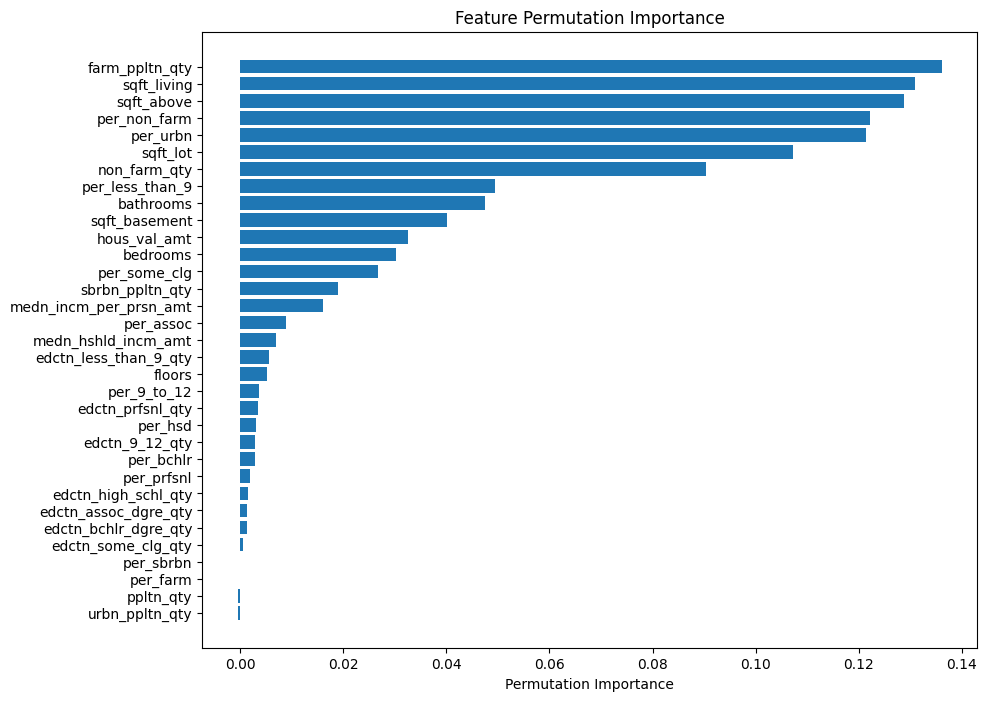

In [26]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

merged_data = df.iloc[X_test.index].merge(demographics, on='zipcode', how='left')[model_features]
result_plot = permutation_importance(current_model, merged_data, y_test, n_repeats=10, random_state=42)
importances_plot = result_plot.importances_mean
sorted_idx = np.argsort(importances_plot)
plt.figure(figsize=(10, 8))
plt.barh(merged_data.columns[sorted_idx], importances_plot[sorted_idx])
plt.xlabel("Permutation Importance")
plt.title("Feature Permutation Importance")
plt.show()

In [27]:
data

,id,date,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,grade,sqft_above,sqft_basement,lat,long,trend,trend_sq,was_renovated,house_age,renovation_age
0,7129300520,2014-10-13,221900.0,3,1.00,1180,1.0,0,0,7,1180,0,47.5112,-122.257,5,25,False,59,2014
1,6414100192,2014-12-09,538000.0,3,2.25,2570,2.0,0,0,7,2170,400,47.7210,-122.319,7,49,True,63,23
2,5631500400,2015-02-25,180000.0,2,1.00,770,1.0,0,0,6,770,0,47.7379,-122.233,9,81,False,82,2015
3,2487200875,2014-12-09,604000.0,4,3.00,1960,1.0,0,0,7,1050,910,47.5208,-122.393,7,49,False,49,2014
4,1954400510,2015-02-18,510000.0,3,2.00,1680,1.0,0,0,8,1680,0,47.6168,-122.045,9,81,False,28,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,263000018,2014-05-21,360000.0,3,2.50,1530,3.0,0,0,8,1530,0,47.6993,-122.346,0,0,False,5,2014
21609,6600060120,2015-02-23,400000.0,4,2.50,2310,2.0,0,0,8,2310,0,47.5107,-122.362,9,81,False,1,2015
21610,1523300141,2014-06-23,402101.0,2,0.75,1020,2.0,0,0,7,1020,0,47.5944,-122.299,1,1,False,5,2014
21611,291310100,2015-01-16,400000.0,3,2.50,1600,2.0,0,0,8,1600,0,47.5345,-122.069,8,64,False,11,2015
